# Análisis de Comportamiento de Clientes
  </h1>
  <p style="color:#7EC8E3; font-size:15px; margin-top:10px; letter-spacing:0.8px;">ConnectaTel · Telecomunicaciones · Latinoamérica</p>
  <hr style="border:0; height:1px; background:linear-gradient(to right, transparent, #7EC8E3, transparent); margin:16px auto; width:65%;">
  <table style="margin:0 auto; color:#B0C8E0; font-size:13px; border-collapse:collapse;">
    <tr><td style="padding:4px 16px; text-align:right; color:#7EC8E3;"><b>Empresa analizada</b></td><td style="padding:4px 16px;">ConnectaTel</td></tr>
    <tr><td style="padding:4px 16px; text-align:right; color:#7EC8E3;"><b>Tipo de estudio</b></td><td style="padding:4px 16px;">Análisis exploratorio de datos (EDA) · Segmentación de clientes</td></tr>
    <tr><td style="padding:4px 16px; text-align:right; color:#7EC8E3;"><b>Periodo analizado</b></td><td style="padding:4px 16px;">2022 – H1 2024</td></tr>
    <tr><td style="padding:4px 16px; text-align:right; color:#7EC8E3;"><b>Analista</b></td><td style="padding:4px 16px;">Marco Rosado</td></tr>
    <tr><td style="padding:4px 16px; text-align:right; color:#7EC8E3;"><b>Año</b></td><td style="padding:4px 16px;">2024</td></tr>
  </table>
</div>

## Contexto del proyecto

**ConnectaTel** es una empresa de telecomunicaciones con operaciones en Latinoamérica. Este análisis evalúa el comportamiento de sus clientes con base en datos registrados hasta 2024, con el objetivo de identificar patrones de consumo, detectar comportamientos atípicos y construir segmentos accionables para el equipo comercial.

El análisis se desarrolla sobre tres datasets:

| Dataset | Descripción |
|---|---|
| `plans.csv` | Planes disponibles: precio, minutos incluidos, GB y costos por exceso |
| `users.csv` | Perfil del cliente: edad, ciudad, fecha de registro, plan y churn |
| `usage.csv` | Detalle de uso real: llamadas y mensajes por evento |

> **Nota metodológica:** Los resultados son descriptivos y exploratorios. Las asociaciones identificadas no implican causalidad.

## Paso 1 — Carga y exploración inicial

Se valida que los tres datasets carguen correctamente, se revisa su estructura y se realiza una inspección preliminar de columnas, tipos de datos y dimensiones.

In [1]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Cargar archivos
plans = pd.read_csv('/Users/marco/Documents/Data_Analysis/Triple Ten/Sprint 7/Sprint7 project/plans.csv')
users = pd.read_csv('/Users/marco/Documents/Data_Analysis/Triple Ten/Sprint 7/Sprint7 project/users_latam.csv')
usage = pd.read_csv('/Users/marco/Documents/Data_Analysis/Triple Ten/Sprint 7/Sprint7 project/usage.csv')

In [3]:
# Vista previa: plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# Vista previa: users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# Vista previa: usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Estructura de los datasets

In [6]:
# Dimensiones de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# Inspección de plans
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [8]:
# Inspección de users
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# Inspección de usage
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


## Paso 2 — Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

`plans` contiene solo 2 registros y no presenta ausentes; no requiere exploración adicional.

In [10]:
# Valores nulos en users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# Valores nulos en usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


<div style="background:#D5F5E3; border-left:5px solid #3BB273; padding:15px 20px; border-radius:0 8px 8px 0; margin:10px 0;">
**✅ Diagnóstico — valores nulos**

**`users`**
- `city`: 11.7% de valores faltantes. Porcentaje aceptable; se investiga e imputa donde corresponda.
- `churn_date`: 88.3% de valores ausentes. Corresponde a clientes activos; los valores presentes (~11.7%) representan bajas confirmadas y se analizan por separado.

**`usage`**
- `duration` y `length`: Los valores ausentes dependen del tipo de evento (`type`). Se analizan en la sección de nulos MAR/MNAR.
- `date`: Menos del 0.1% de ausentes. Puede ignorarse sin impacto en el análisis.
</div>

### 2.2 Detección de valores inválidos y sentinels

`plans` se excluye de esta exploración por su tamaño reducido.

In [12]:
# Estadísticas de columnas numéricas de users
numeric_col = ['user_id', 'age']

for col in numeric_col:
    print(f"\n{'='*35}")
    print(f"--- Estadísticas de {col.upper()} ---")
    print(f"{'='*35}")
    print(users[col].describe())


--- Estadísticas de USER_ID ---
count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

--- Estadísticas de AGE ---
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


<div style="background:#D5F5E3; border-left:5px solid #3BB273; padding:15px 20px; border-radius:0 8px 8px 0; margin:10px 0;">
**✅ Diagnóstico — columnas numéricas (users)**

- `user_id`: Sin valores atípicos. Identificador limpio.
- `age`: Se detectan valores de **-999** (sentinel). Requieren reemplazo.
</div>

In [13]:
# Estadísticas de columnas numéricas de usage
numeric_col = ['id', 'user_id']

for col in numeric_col:
    print(f"\n{'='*35}")
    print(f"--- Estadísticas de {col.upper()} ---")
    print(f"{'='*35}")
    print(usage[col].describe())


--- Estadísticas de ID ---
count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

--- Estadísticas de USER_ID ---
count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64


<div style="background:#D5F5E3; border-left:5px solid #3BB273; padding:15px 20px; border-radius:0 8px 8px 0; margin:10px 0;">
**✅ Diagnóstico — columnas numéricas (usage)**

El dataset contiene 40,000 registros para 4,000 usuarios únicos. La granularidad es a nivel de evento (transacción por usuario), no a nivel de usuario. Las métricas de comportamiento deben calcularse con agregaciones por `user_id`.
</div>

In [14]:
# Columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\n{'='*35}")
    print(f"--- Estadísticas de {col.upper()} ---")
    print(f"{'='*35}")
    print(users[col].describe())
    print(users[col].value_counts())


--- Estadísticas de CITY ---
count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object
city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64

--- Estadísticas de PLAN ---
count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object
plan
Basico     2595
Premium    1405
Name: count, dtype: int64


<div style="background:#D5F5E3; border-left:5px solid #3BB273; padding:15px 20px; border-radius:0 8px 8px 0; margin:10px 0;">
**✅ Diagnóstico — columnas categóricas (users)**

- `city`: Bogotá concentra el 22% de los usuarios (la más frecuente de 7 ciudades).
- `plan`: El **64.8%** de los usuarios tiene plan Básico, lo que condiciona la segmentación posterior.
</div>

In [15]:
# Columna categórica de usage
usage_cat = ['type']

for col in usage_cat:
    print(f"\n{'='*35}")
    print(f"--- Estadísticas de {col.upper()} ---")
    print(f"{'='*35}")
    print(usage[col].describe())


--- Estadísticas de TYPE ---
count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


<div style="background:#D5F5E3; border-left:5px solid #3BB273; padding:15px 20px; border-radius:0 8px 8px 0; margin:10px 0;">
**✅ Diagnóstico — columnas categóricas (usage)**

- `type`: Variable binaria (`call` / `text`). Leve predominancia de `text` (55%).
</div>

### 2.3 Revisión y estandarización de fechas

Se verifican rangos válidos y se identifican fechas fuera del período de análisis (2022–2024).

In [16]:
# Convertir reg_date a tipo fecha
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir date a tipo fecha
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Años presentes en reg_date
users['reg_date'].unique()

<DatetimeArray>
[          '2022-01-01 00:00:00', '2022-01-01 06:34:17.914478619',
 '2022-01-01 13:08:35.828957239', '2022-01-01 19:42:53.743435858',
 '2022-01-02 02:17:11.657914478', '2022-01-02 08:51:29.572393098',
 '2022-01-02 15:25:47.486871717', '2022-01-02 22:00:05.401350337',
 '2022-01-03 04:34:23.315828957', '2022-01-03 11:08:41.230307576',
 ...
 '2024-12-28 12:51:18.769692432', '2024-12-28 19:25:36.684171056',
 '2024-12-29 01:59:54.598649664', '2024-12-29 08:34:12.513128288',
 '2024-12-29 15:08:30.427606912', '2024-12-29 21:42:48.342085520',
 '2024-12-30 04:17:06.256564144', '2024-12-30 10:51:24.171042768',
 '2024-12-30 17:25:42.085521392',           '2024-12-31 00:00:00']
Length: 3961, dtype: datetime64[ns]

In [19]:
# Años presentes en date de usage
usage['date'].unique()
usage['date'].tail()

39995   2024-06-29 23:33:56.120903022
39996   2024-06-29 23:40:27.090677266
39997   2024-06-29 23:46:58.060451510
39998   2024-06-29 23:53:29.030225754
39999   2024-06-30 00:00:00.000000000
Name: date, dtype: datetime64[ns]

<div style="background:#D5F5E3; border-left:5px solid #3BB273; padding:15px 20px; border-radius:0 8px 8px 0; margin:10px 0;">
**✅ Diagnóstico — fechas**

- `reg_date`: Registros del 01/01/2022 al 31/12/2024. Sin fechas fuera de rango.
- `date` (usage): Datos del primer semestre de 2024 (01/01/2024 – 30/06/2024). El análisis de uso se limita a este período.

Próximos pasos: agrupar `reg_date` por período para analizar crecimiento y abandono; analizar `date` de usage por día dentro del semestre.
</div>

## Paso 3 — Limpieza de datos

### 3.1 Corrección de sentinels y fechas fuera de rango

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts()

city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: count, dtype: int64

In [22]:
# Marcar fechas fuera de rango como NA
fecha_minima = pd.Timestamp('2022-01-01')
fecha_maxima = pd.Timestamp('2024-12-31')
print(f"Rango válido: {fecha_minima} a {fecha_maxima}")

print(f"\n{'='*35}")
print("Antes de la limpieza:")
fechas_muy_antiguas = users['reg_date'] < fecha_minima
fechas_futuras = users['reg_date'] > fecha_maxima

print(f"Fechas muy antiguas: {fechas_muy_antiguas.sum()}")
print(f"Fechas futuras: {fechas_futuras.sum()}")
print(f"Total NA en reg_date: {users['reg_date'].isna().sum()}")

print(f"\n{'='*35}")
print("Después de la limpieza:")
users.loc[users['reg_date'] > fecha_maxima, 'reg_date'] = pd.NaT

print(f"Fechas futuras: {fechas_futuras.sum()}")
print(f"Total NA en reg_date: {users['reg_date'].isna().sum()}")
users['reg_date'].describe()

Rango válido: 2022-01-01 00:00:00 a 2024-12-31 00:00:00

Antes de la limpieza:
Fechas muy antiguas: 0
Fechas futuras: 40
Total NA en reg_date: 0

Después de la limpieza:
Fechas futuras: 40
Total NA en reg_date: 40


count                             3960
mean     2023-07-03 21:39:41.095273728
min                2022-01-01 00:00:00
25%      2022-10-02 20:17:11.657914368
50%      2023-07-04 10:00:05.401350400
75%      2024-04-03 04:00:05.401350400
max                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Tratamiento de nulos en variables de uso

Se verifica si los nulos en `duration` y `length` son Missing At Random (MAR) o Missing Not At Random (MNAR) respecto a `type`.

In [23]:
# Verificación MNAR en usage para duration
usage['duration'].isna().groupby(usage['type']).sum().sort_values(ascending=False)

type
text    22076
call        0
Name: duration, dtype: int64

In [24]:
# Verificación MNAR en usage para length
usage['length'].isna().groupby(usage['type']).sum().sort_values(ascending=False)

type
call    17896
text        0
Name: length, dtype: int64

<div style="background:#F5EEF8; border-left:5px solid #8E44AD; padding:15px 20px; border-radius:0 8px 8px 0; margin:10px 0;">
**📝 Nota metodológica — nulos en duration y length**

Los valores ausentes no son aleatorios: dependen directamente de la variable `type`.

- Para registros `text`, `duration` no aplica (una llamada no tiene duración medida en este contexto).
- Para registros `call`, `length` no aplica (un mensaje no tiene longitud de llamada).

Se clasifican como **MNAR** (Missing Not At Random). No se imputan ni eliminan. Se analizan por subconjunto según `type`.
</div>

## Paso 4 — Métricas de uso por usuario

### 4.1 Agregación por usuario

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Agrupar por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
    }).reset_index()

usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"})

usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 Resumen estadístico del perfil de usuario (H1 2024)

In [28]:
# Detectar usuarios inactivos
usuarios_inactivos = user_profile[
    (user_profile['cant_mensajes'] == 0) &
    (user_profile['cant_llamadas'] == 0) &
    (user_profile['cant_minutos_llamada'] == 0)]
print(usuarios_inactivos)

# Resumen estadístico de columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    print(f"\nResumen de {col}:")
    print(user_profile[col].describe())

Empty DataFrame
Columns: [user_id, first_name, last_name, age, city, reg_date, plan, churn_date, cant_mensajes, cant_llamadas, cant_minutos_llamada]
Index: []

Resumen de age:
count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

Resumen de cant_mensajes:
count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64

Resumen de cant_llamadas:
count    3999.000000
mean        4.478120
std         2.144238
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64

Resumen de cant_minutos_llamada:
count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%     

In [29]:
# Distribución porcentual del plan
(user_profile['plan'].value_counts(normalize=True) * 100).round(2)

plan
Basico     64.88
Premium    35.12
Name: proportion, dtype: float64

## Paso 5 — Visualización de distribuciones y detección de outliers

### 5.1 Distribuciones por tipo de plan

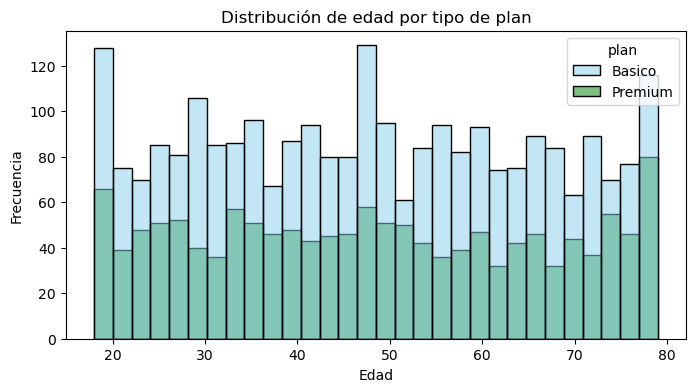

In [30]:
# Distribución de edad por plan
plt.figure(figsize=(8,4))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], bins=30)
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

<div style="background:#D5F5E3; border-left:5px solid #3BB273; padding:15px 20px; border-radius:0 8px 8px 0; margin:10px 0;">
**✅ Observación**

Distribución estable y consistente. No se observa un patrón entre edad y tipo de plan. La mayor frecuencia absoluta en el plan Básico refleja su predominancia en la base de clientes.
</div>

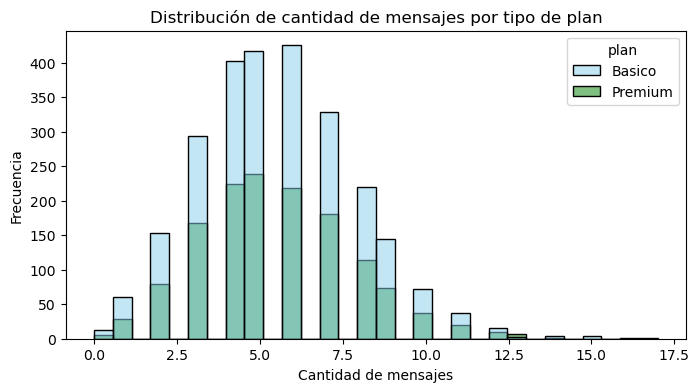

In [31]:
# Distribución de mensajes por plan
plt.figure(figsize=(8,4))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], bins=30)
plt.title('Distribución de cantidad de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

<div style="background:#D5F5E3; border-left:5px solid #3BB273; padding:15px 20px; border-radius:0 8px 8px 0; margin:10px 0;">
**✅ Observación**

Los usuarios Premium concentran los volúmenes más altos de mensajes. La distribución presenta sesgo moderado hacia la derecha, impulsado por este segmento.
</div>

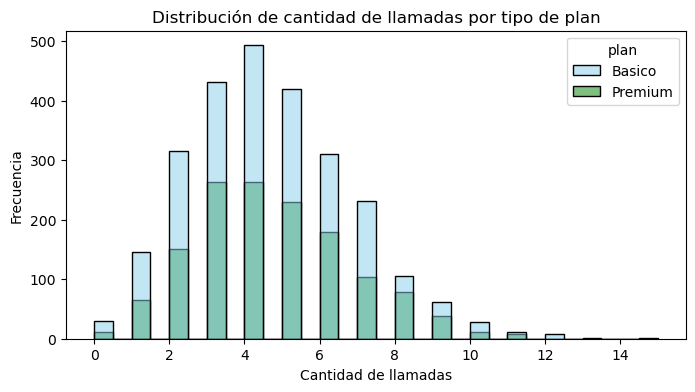

In [32]:
# Distribución de llamadas por plan
plt.figure(figsize=(8,4))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], bins=30)
plt.title('Distribución de cantidad de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

<div style="background:#D5F5E3; border-left:5px solid #3BB273; padding:15px 20px; border-radius:0 8px 8px 0; margin:10px 0;">
**✅ Observación**

Distribución sesgada hacia la derecha, sin valores extremos. La frecuencia de llamadas es similar entre planes en los rangos bajos.
</div>

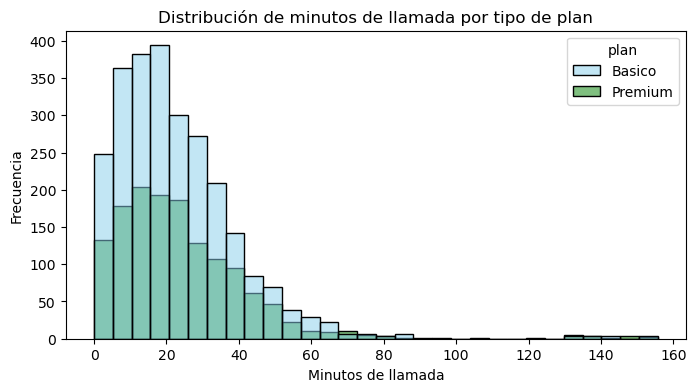

In [33]:
# Distribución de minutos de llamada por plan
plt.figure(figsize=(8,4))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], bins=30)
plt.title('Distribución de minutos de llamada por tipo de plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

<div style="background:#FEF9E7; border-left:5px solid #F7B731; padding:15px 20px; border-radius:0 8px 8px 0; margin:10px 0;">
**⚠️ Observación — sesgo significativo**

Fuerte asimetría positiva. Un segmento reducido de usuarios Premium concentra un volumen elevado de minutos, generando una distribución altamente desigual. Esta variable requiere análisis adicional en la sección de outliers.
</div>

### 5.2 Identificación y tratamiento de outliers

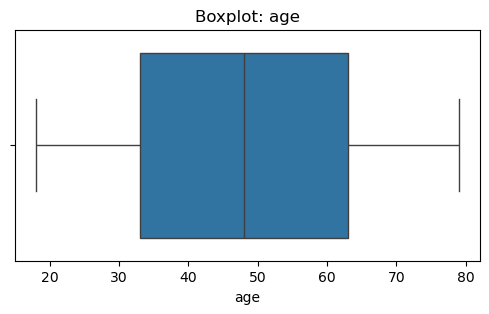

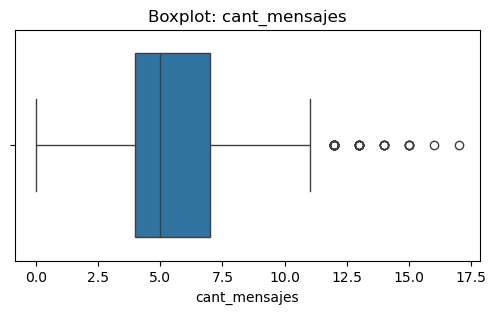

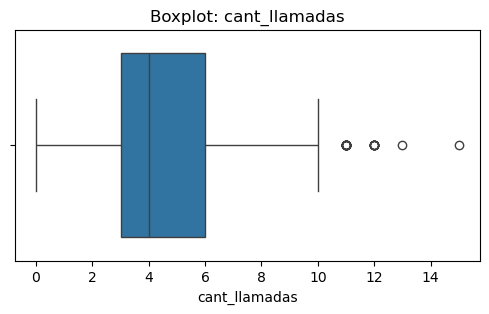

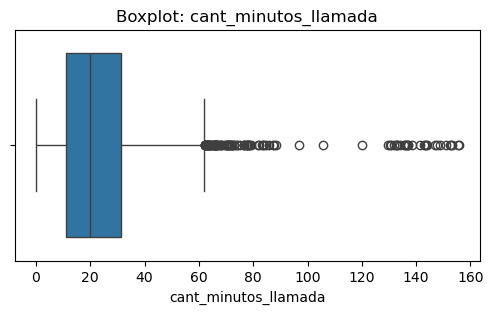

In [34]:
# Boxplots por variable numérica clave
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,3))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

<div style="background:#D5F5E3; border-left:5px solid #3BB273; padding:15px 20px; border-radius:0 8px 8px 0; margin:10px 0;">
**✅ Diagnóstico — outliers por variable**

- `age`: Sin outliers. Distribución estable.
- `cant_mensajes`: Outliers moderados en el extremo superior. Usuarios con mayor actividad dentro de rangos esperados.
- `cant_llamadas`: Comportamiento similar a mensajes. Outliers leves, sin anomalías críticas.
- `cant_minutos_llamada`: Outliers significativos con fuerte asimetría positiva. Un segmento reducido concentra el volumen de consumo.
</div>

In [35]:
# Límites IQR para variables con outliers
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"{col}")
    print(f"Límite superior: {limite_superior}")
    print(f"Máximo real: {user_profile[col].max()}")
    print("-"*30)

cant_mensajes
Límite superior: 11.5
Máximo real: 17.0
------------------------------
cant_llamadas
Límite superior: 10.5
Máximo real: 15.0
------------------------------
cant_minutos_llamada
Límite superior: 61.8575
Máximo real: 155.69
------------------------------


In [36]:
# Estadísticas descriptivas de las variables con outliers
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


<div style="background:#D5F5E3; border-left:5px solid #3BB273; padding:15px 20px; border-radius:0 8px 8px 0; margin:10px 0;">
**✅ Decisión — mantener outliers**

- `cant_mensajes`: Máximo (17) supera el límite IQR (≈11.5), pero la desviación es moderada y consistente con comportamiento real de usuarios activos.
- `cant_llamadas`: Máximo (15) excede el límite (≈10.5). La diferencia no sugiere error de captura; representa una cola de usuarios con mayor frecuencia de uso.
- `cant_minutos_llamada`: Máximo (≈155.69) muy superior al límite (≈61.86) y a la mediana (≈19.78). Corresponde a usuarios intensivos. Se conservan y se tratarán mediante segmentación en el paso siguiente.
</div>

## Paso 6 — Segmentación de clientes

### 6.1 Segmentación por nivel de uso

In [37]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [38]:
# Verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación por grupo de edad

In [39]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [40]:
# Verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de segmentos

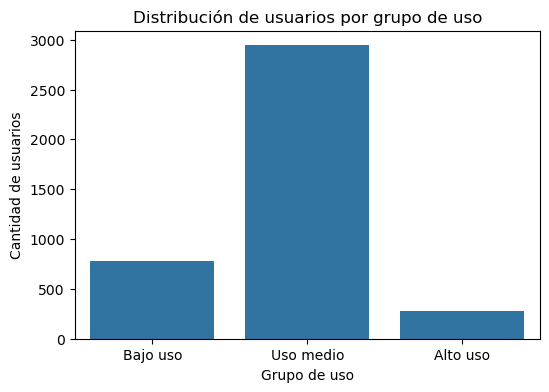

In [41]:
# Distribución por grupo de uso
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso','Uso medio','Alto uso'])
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

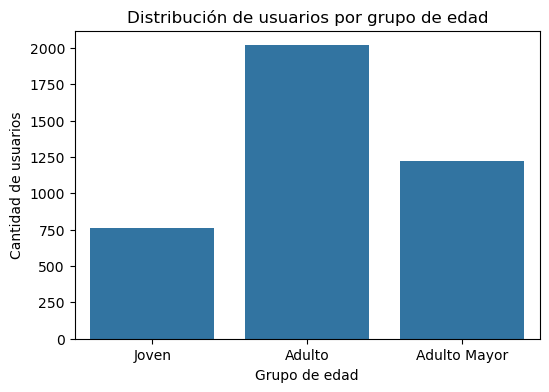

In [42]:
# Distribución por grupo de edad
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven','Adulto','Adulto Mayor'])
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

## Paso 7 — Insight ejecutivo para stakeholders

### Calidad de datos

Se identificaron tres problemas en los datos originales:

- **`age`**: Valores sentinel (-999). Reemplazados con la mediana del campo válido.
- **`city`**: Valores inválidos ("?") y 11.7% de ausentes. Los caracteres inválidos se marcaron como nulos; los ausentes se conservaron al corresponder a clientes sin ciudad registrada.
- **`reg_date`**: Sin fechas fuera del rango 2022–2024. No se requirió limpieza adicional.

Los outliers en variables de uso no son errores de captura; representan comportamiento real de usuarios intensivos.

<div style="background:#D5F5E3; border-left:5px solid #3BB273; padding:15px 20px; border-radius:0 8px 8px 0; margin:10px 0;">
**✅ Segmentación por edad**

La distribución de edad es uniforme y sin outliers relevantes. El segmento **Adulto (30–59 años)** es el predominante en la base de clientes.
</div>

<div style="background:#D5F5E3; border-left:5px solid #3BB273; padding:15px 20px; border-radius:0 8px 8px 0; margin:10px 0;">
**✅ Segmentación por nivel de uso**

Se identificaron tres segmentos:
- **Bajo uso**: usuarios con baja interacción (pocas llamadas y mensajes).
- **Uso medio**: segmento mayoritario, con comportamiento estable y predecible.
- **Alto uso**: segmento reducido que concentra la mayor parte del consumo, especialmente en minutos de llamada.

La distribución sigue un patrón típico: pocos usuarios concentran gran parte del uso.
</div>

<div style="background:#FEF9E7; border-left:5px solid #F7B731; padding:15px 20px; border-radius:0 8px 8px 0; margin:10px 0;">
**⚠️ Acciones prioritarias para el negocio**

**1. Optimización del plan Premium**
Los usuarios de alto uso deben estar correctamente monetizados. Usuarios intensivos en plan Básico representan ingresos no capturados.

**2. Plan intermedio ("Pro")**
El salto entre Básico y Premium puede estar generando fricción. Un nivel intermedio captura la transición de uso medio a alto.

**3. Estrategia de upselling**
Identificar usuarios de uso medio próximos al umbral de alto uso e incentivar migración a planes superiores antes de que el comportamiento se estabilice.
</div>

## Repositorio en GitHub

El proyecto está disponible públicamente en:

```
https://github.com/Marco-Rosado/telecom-analysis/tree/main
```

El repositorio incluye el notebook completo y un archivo `README.md` con:
- Objetivo del proyecto
- Descripción de los datasets utilizados
- Etapas del análisis realizadas
